In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [25]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [13]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [4]:
df.shape
# yaha pr Aceage(Hectare) matlab us country ke pass kitna jamin hai sugarcane ugane ke liye
# aur yeild wala matlab 1 hecatre me kitne kg sugarcane utpana hue hai

(103, 7)

## Data cleaning

In [26]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"] = df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [6]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [27]:
df.rename(columns = {"Production (Tons)" : "Production(Tons)"}, inplace = True)
df.rename(columns = {"Production per Person (Kg)" : "Production_per_Person(Kg)"}, inplace = True)
df.rename(columns = {"Acreage (Hectare)" : "Acreage(Hectare)"}, inplace = True)
df.rename(columns = {"Yield (Kg / Hectare)" : "Yield(Kg / Hectare)"}, inplace = True)

In [8]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [9]:
df.isnull().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_Person(Kg)    0
Acreage(Hectare)             1
Yield(Kg / Hectare)          1
dtype: int64

In [28]:
df[df["Acreage(Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [12]:
df = df.dropna().reset_index()

In [13]:
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [ ]:
df.drop(["index", "unnamed: 0"], axis = 1, inplace = True)
#yea code mam pada rahe hai unke hisab se likhe hai pr yea code m error aa raha hai is liye chatgpt use krke niche wala code sahi kiya hu

In [20]:
df.drop(["index", "Unnamed: 0"], axis=1, inplace=True)


In [21]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [23]:
df.dtypes

Country                      object
Continent                    object
Production(Tons)             object
Production_per_Person(Kg)    object
Acreage(Hectare)             object
Yield(Kg / Hectare)          object
dtype: object

In [29]:
df["Production(Tons)"] = df["Production(Tons)"].astype(float)
df["Production_per_Person(Kg)"] = df["Production_per_Person(Kg)"].astype(float)
df["Acreage(Hectare)"] = df["Acreage(Hectare)"].astype(float)
df["Yield(Kg / Hectare)"] = df["Yield(Kg / Hectare)"].astype(float)


In [79]:
df.dtypes

Unnamed: 0                     int64
Country                       object
Continent                     object
Production(Tons)             float64
Production_per_Person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg / Hectare)          float64
dtype: object

In [26]:
df.nunique()

Country                      102
Continent                      6
Production(Tons)             102
Production_per_Person(Kg)    101
Acreage(Hectare)             101
Yield(Kg / Hectare)          102
dtype: int64

## Univariate Analysis

In [27]:
 df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


## How many countries produce sugarcane from each continent?

In [30]:
df["Continent"].value_counts()

Continent
Africa           39
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

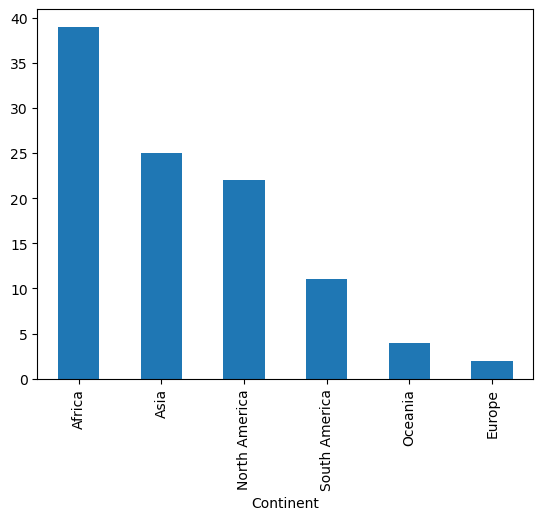

In [31]:
df["Continent"].value_counts().plot(kind = "bar")
# yea graph matplotlib library ka use krke banaye hai

## distribution of columns

C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_44964\946582949.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_44964\946582949.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_Person(Kg)"

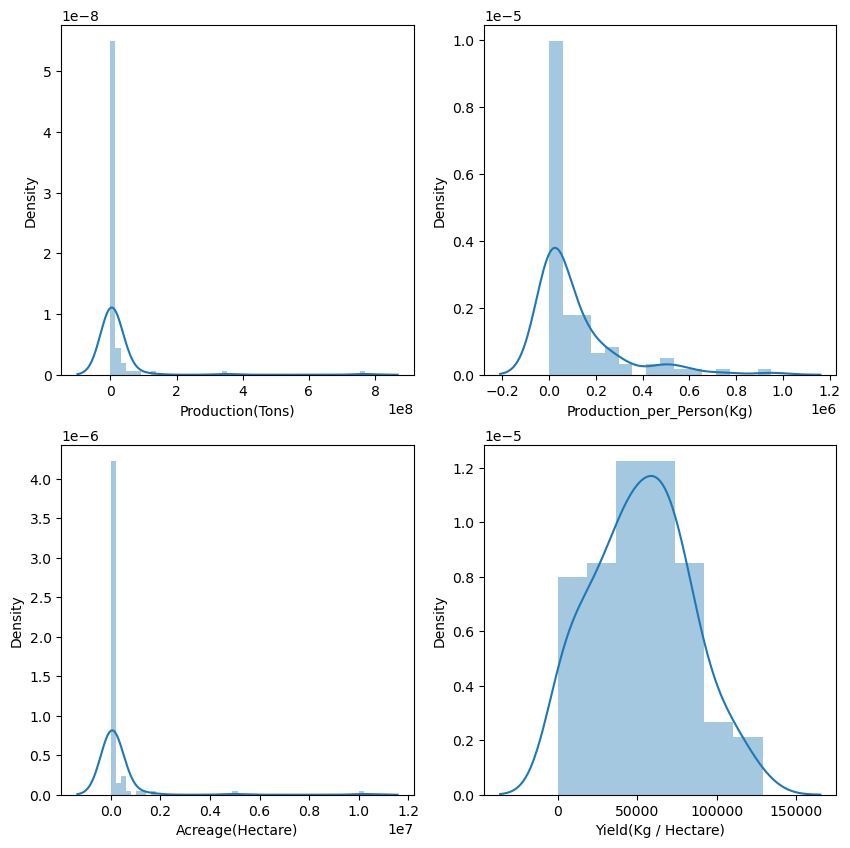

In [32]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg / Hectare)"])
plt.show()

## Removing Outliers

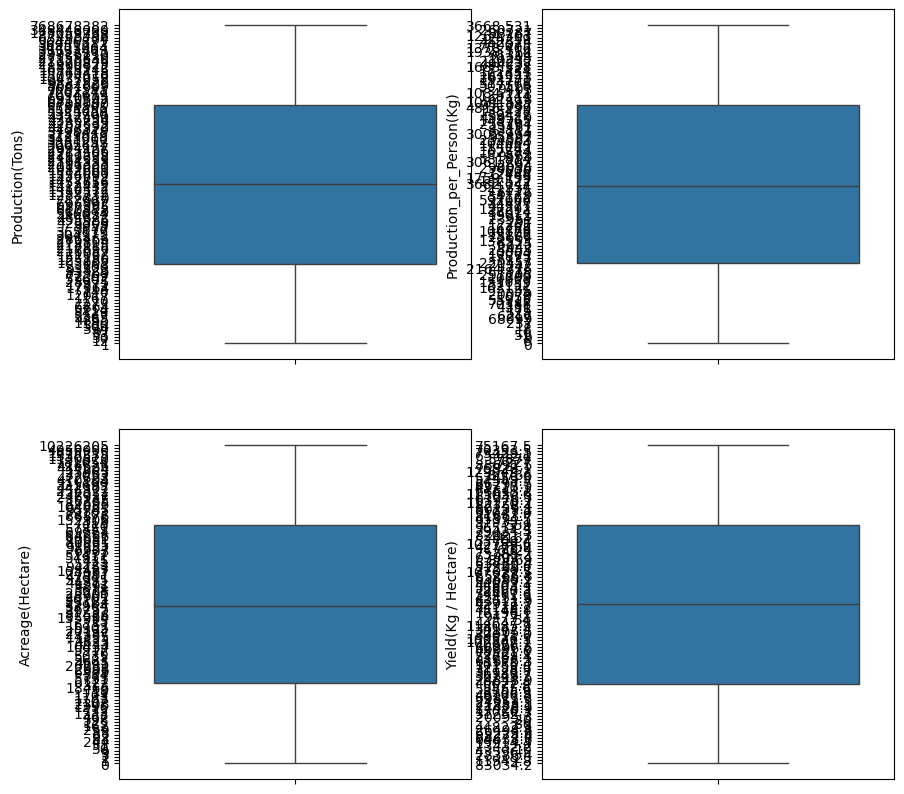

In [19]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg / Hectare)"])
plt.show()

In [39]:
df.describe()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


## Bivariate Analysis 

In [40]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


### Which country produces maximum sugarcanes?

In [21]:
df_new = df[["Country", "Production(Tons)"]].set_index("Country")

In [22]:
df_new

,Production(Tons)
Country,
Brazil,768678382
India,348448000
China,123059739
Thailand,87468496
Pakistan,65450704
...,...
Lebanon,97
Djibouti,53
Singapore,50


In [23]:
df_new["Production(Tons)_percent"] = df_new["Production(Tons)"]*100/df_new["Production(Tons)"].sum()

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [24]:
df_new

,Production(Tons)
Country,
Brazil,768678382
India,348448000
China,123059739
Thailand,87468496
Pakistan,65450704
...,...
Lebanon,97
Djibouti,53
Singapore,50


<Axes: ylabel='Production(Tons)_percent'>

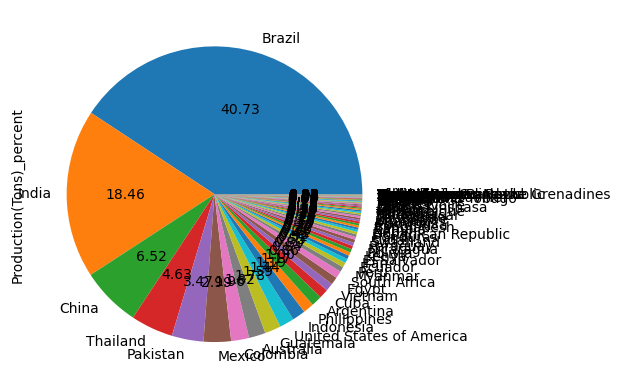

In [46]:
df_new["Production(Tons)_percent"].plot(kind = "pie", autopct = "%.2f")

<Axes: xlabel='Country'>

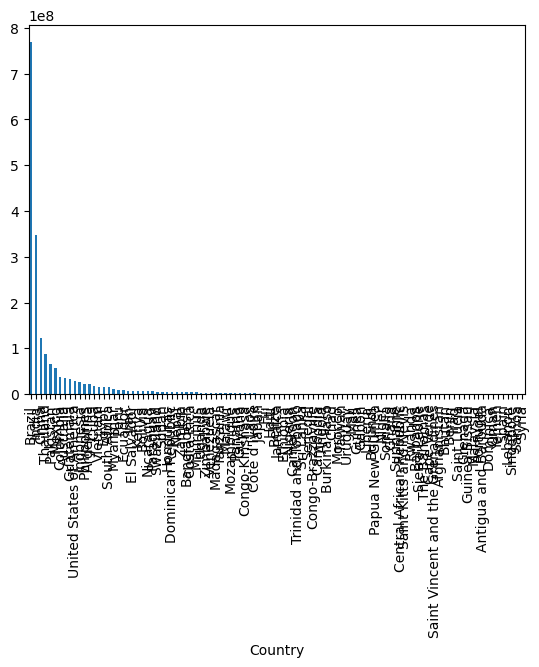

In [50]:
df_new["Production(Tons)"].plot(kind = "bar")

In [57]:
df.head(10)

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
5,Mexico,North America,56446821.0,452524.000,781054.0,7227.0
6,Colombia,South America,36951213.0,740075.000,416626.0,88691.5
7,Australia,Oceania,34403004.0,1373.406,447204.0,76929.1
8,Guatemala,North America,33533403.0,1938.114,25985.0,129049.3
9,United States of America,North America,29926210.0,91304.000,37053.0,80766.0


<Axes: xlabel='Country'>

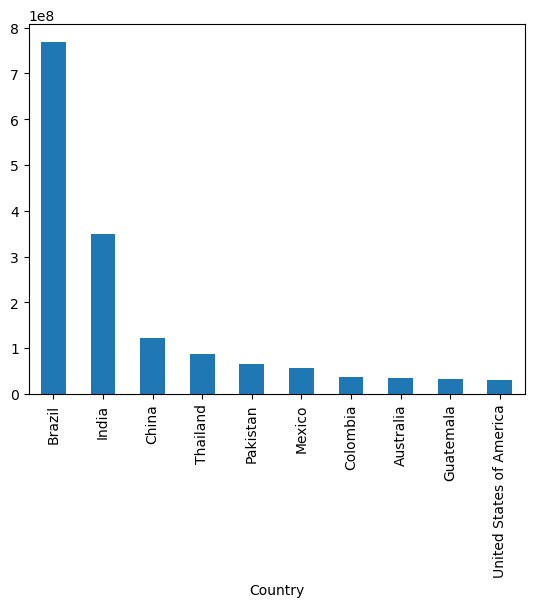

In [52]:
df_new["Production(Tons)"].head(10).plot(kind = "bar")
# yea 10 country ka hai

C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_16776\1773840075.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


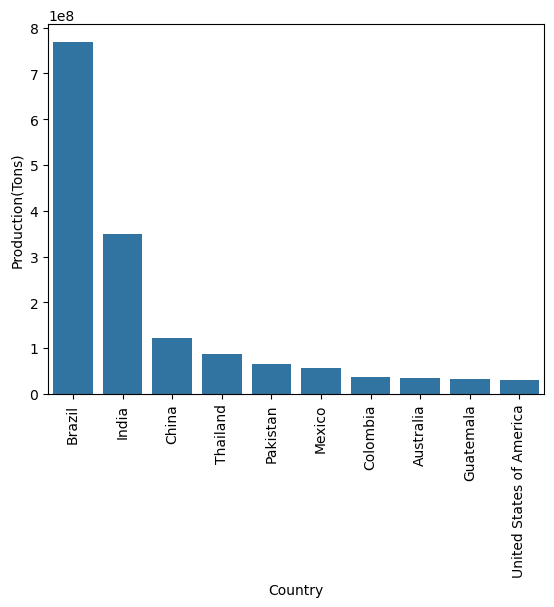

In [54]:
# use seaborn library
ax = sns.barplot(data = df.head(10), x = "Country", y = "Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

### which country has highest land?

C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_16776\2603056855.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


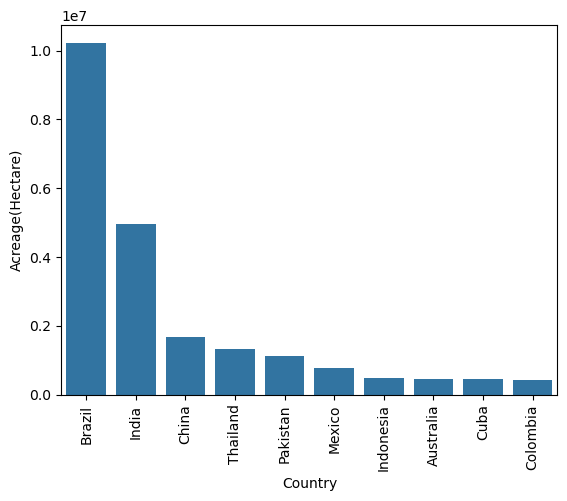

In [64]:
df_acr = df.sort_values("Acreage(Hectare)", ascending = False)
ax = sns.barplot(data = df_acr.head(10), x = "Country", y = "Acreage(Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

### Which country has highest yield per hectare?

C:\Users\Shivam Shekhar\AppData\Local\Temp\ipykernel_16776\4067595004.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


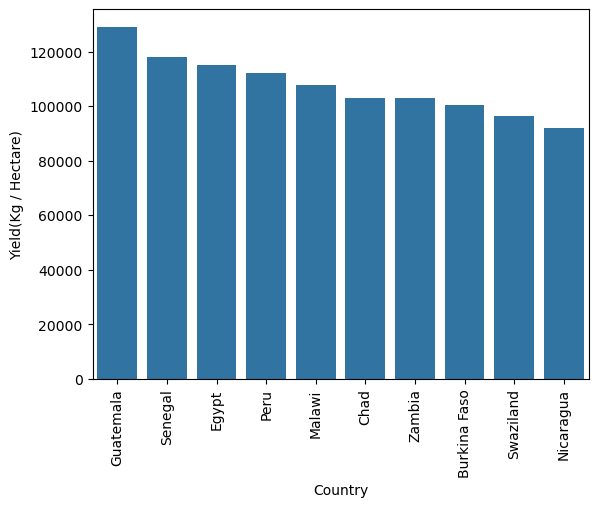

In [68]:
df_yield = df.sort_values("Yield(Kg / Hectare)", ascending = False)
ax = sns.barplot(data = df_yield.head(10), x = "Country", y = "Yield(Kg / Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

### Which country has highest production?

### Correlation

### Do countries with highest land produce more sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

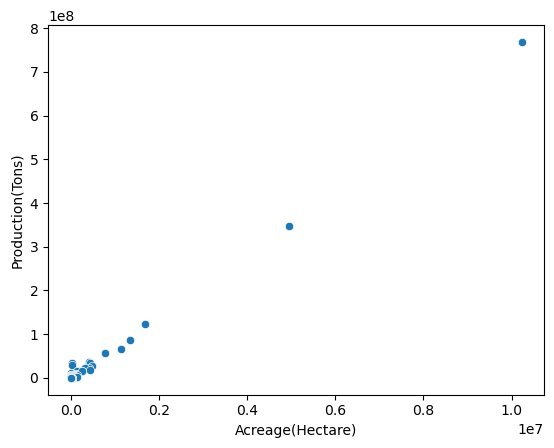

In [95]:
sns.scatterplot(data = df, x = "Acreage(Hectare)", y = "Production(Tons)")

### Do countries which yield more sugarcane per hectare produces more sugarcane in total?

<Axes: xlabel='Yield(Kg / Hectare)', ylabel='Production(Tons)'>

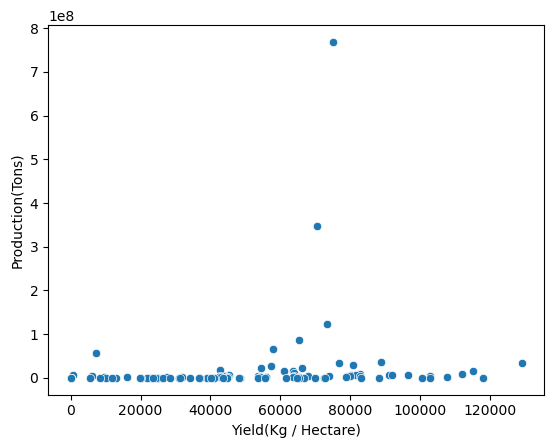

In [96]:
sns.scatterplot(data = df, x = "Yield(Kg / Hectare)", y = "Production(Tons)")

## Analysis for Continent

In [98]:
df_continent = df.groupby("Continent").sum()

In [99]:
df_continent

,Unnamed: 0,Country,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
Continent,,,,,,
Africa,2160,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681525,2332686,1439089,2142092
Asia,1253,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425,1857769,10608319,1171862
Europe,189,PortugalSpain,5823,536,71,131870
North America,1101,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947,3796080,1581983,1082595
Oceania,227,AustraliaFijiPapua New GuineaSamoa,36177574,28593,490909,162417
South America,323,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126,3505531,11369236,677188


### Which continent produces maximum sugarcane?

In [103]:
df["Continent"].value_counts()

Continent
Africa           39
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

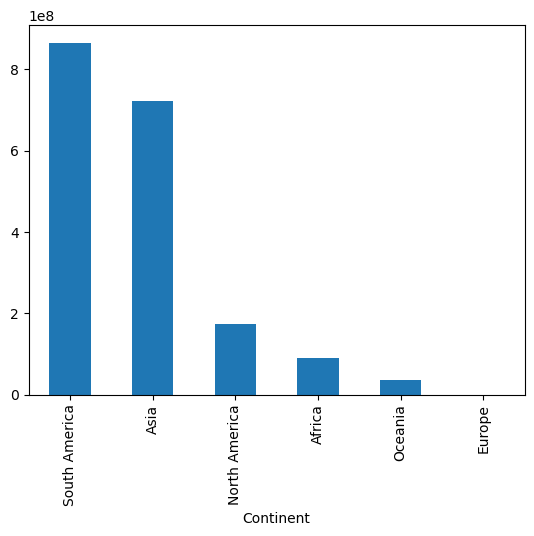

In [101]:
df_continent["Production(Tons)"].sort_values(ascending = False).plot(kind = "bar")

<Axes: xlabel='Continent'>

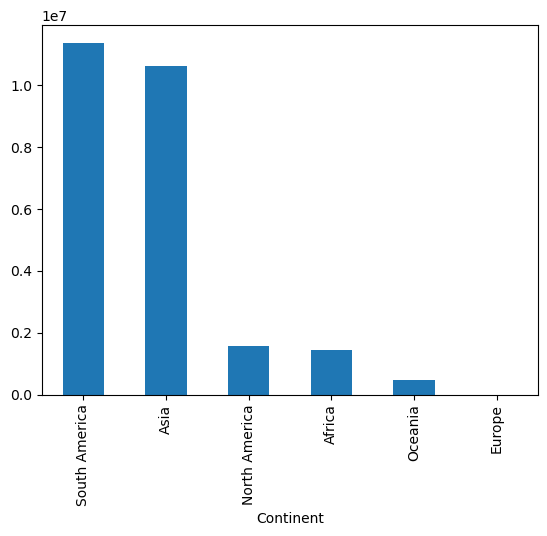

In [105]:
df_continent["Acreage(Hectare)"].sort_values(ascending = False).plot(kind = "bar")

### Do number of countries in a Continent effects production of sugarcane?

In [108]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]

In [109]:
df_continent

,Unnamed: 0,Country,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg / Hectare),number_of_countries
Continent,,,,,,,
Africa,2160,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681525,2332686,1439089,2142092,39
Asia,1253,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425,1857769,10608319,1171862,25
Europe,189,PortugalSpain,5823,536,71,131870,2
North America,1101,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947,3796080,1581983,1082595,22
Oceania,227,AustraliaFijiPapua New GuineaSamoa,36177574,28593,490909,162417,4
South America,323,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126,3505531,11369236,677188,11


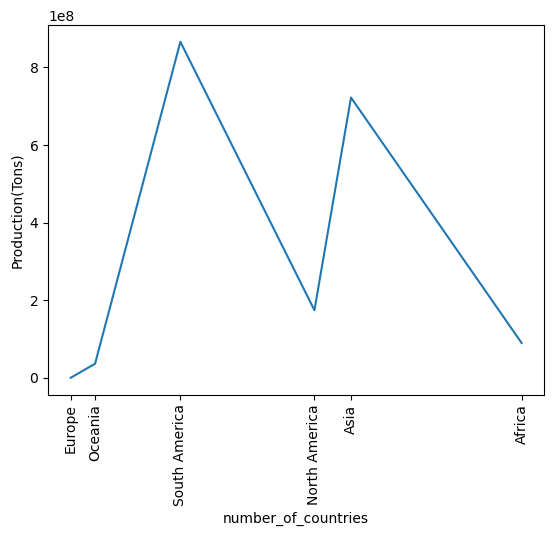

In [112]:
Continent_names = df_continent.index.tolist()
sns.lineplot(data = df_continent, x = "number_of_countries", y = "Production(Tons)")
plt.xticks(df_continent["number_of_countries"], continent_names, rotation = 90)
plt.show()

### Production distribution by continent

<Axes: ylabel='Production(Tons)'>

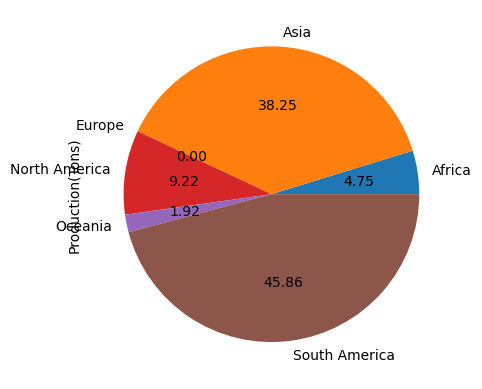

In [114]:
df_continent["Production(Tons)"].plot(kind = "pie",autopct = "%.2f")